### Libraries.

In [ ]:
import sys

import fastkde
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from torchdiffeq import odeint
from tqdm import tqdm

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.metrics import compute_e_distance, compute_mmd
from sc_exp_design.models import FlowMatching
from sc_exp_design.ode.solvers import VF

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE

sys.path.insert(0, "../../scripts")
from fetch_data import fetch_adata_goattgens_sfc, EXPERIMENTAL_COLUMNS


### Loading the Data.

In [ ]:
H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/HID01_fcs_concatenated_logicle.h5ad"
COFACTOR = 3e3
OBSM_KEY = "X_repr"
OBS_KEY = "protocol"
UNS_KEY = "ohe"
adata = fetch_adata_goattgens_sfc(
    H5AD_PATH,
    mode="protocol_one_hot",
    transformation="arcsinh",
    protocol_columns=["740-yp_[µm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]", "tpo_[ng_ml]", "sr1_[nm]", "um171_[nm]", "um729_[µm]", "scf_[ng_ml]", "butyzamide_[nm]", "retinoic_acid_[µm]", "ldl_[ng_ml]", "il3_[ng_ml]", "o2_[%]", "days_of_culture"],
    cofactor=COFACTOR,
    obsm_key_added=OBSM_KEY,
    obs_key_added=OBS_KEY,
    uns_key_added=UNS_KEY,
)
adata


AnnData object with n_obs × n_vars = 93275454 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'ohe'
    obsm: 'X_repr'
    layers: 'positives', 'raw'

### Initializing flow matching model.

In [ ]:
FLOW_DIM = adata.obsm[OBSM_KEY].shape[1]
COND_REPR = f"repr_{OBS_KEY}_{UNS_KEY}"
PERT_INPUT_DIM = list(adata.uns[UNS_KEY].values())[0].shape[0]
flow_matching = FlowMatching(
    flow_type="rectified",
    coupling_type="independent",
    generate_from_noise=True,
)

flow_matching.prepare_train_data(
    adata,
    sample_rep=OBSM_KEY,
    control_key=None,
    perturbations=(OBS_KEY,),
    perturbation_reps={OBS_KEY: (UNS_KEY, )},
)


### Preparing Neural VF.

In [ ]:
cvf_config = NeuralVelocityFieldConfig(
    FLOW_DIM,

    encode_state=True,
    use_sinusoidal_time_features=True,
    encode_time=True,
    use_guidance=True,
    encode_conditions=True,

    state_encoder_output_dim=16,
    time_encoder_output_dim=16,
    perturbation_encoder_output_dim=16,

    state_encoder_mlp_kwargs={"hidden_dims": (128,), "activation_class": torch.nn.SELU},
    time_encoder_mlp_kwargs={"hidden_dims": (128,), "activation_class": torch.nn.SELU},
    decoder_mlp_kwargs={"hidden_dims": (128, 128,), "activation_class": torch.nn.SELU},

    perturbation_layers_before_pooling={
        COND_REPR: {
            "input_dim": PERT_INPUT_DIM,
            "output_dim": 16,
            "hidden_dims": (128,),
            "activation_class": torch.nn.SELU,
        }
    },
    perturbation_layers_after_pooling={"hidden_dims": (128,), "activation_class": torch.nn.SELU}
)
flow_matching.prepare_model(
    cvf_config,
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr":0.0001},
    solver_kwargs={"method": "euler"},
    num_time_steps=10,
)
flow_matching.velocity_field


NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=21, out_features=128, bias=True)
          (1): SELU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): SELU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (condition_encoder): ConditionEncoder(
      (modules_dict): ModuleDict(
        (repr_protocol_ohe): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=117, out_features=128, bias=True)
              (1): SELU()
            )
            (1): Sequenti

### Training CFM model.

Loss: 0.2429: 100%|██████████| 100000/100000 [06:04<00:00, 274.65it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

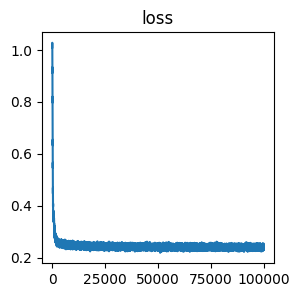

In [ ]:
TRAIN_BATCH_SIZE = 1024
NUM_GRAD_STEPS = 100_000
flow_matching.train(
    NUM_GRAD_STEPS,
    train_batch_size=TRAIN_BATCH_SIZE,
)

flow_matching.trainer.plot_training_logs()


### Subsampling the data


In [ ]:
adata_subsample = adata.copy()
sc.pp.sample(adata_subsample, fraction=0.001)
adata_subsample.layers[OBSM_KEY] = adata_subsample.obsm[OBSM_KEY]
adata_subsample


AnnData object with n_obs × n_vars = 93275 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'ohe'
    obsm: 'X_repr'
    layers: 'positives', 'raw', 'X_repr'

### Compute PCs, Neighbor Graph and UMAP of Data.

In [ ]:
sc.pp.pca(adata_subsample, layer=OBSM_KEY)
sc.pp.neighbors(adata_subsample)
sc.tl.umap(adata_subsample)
adata_subsample


AnnData object with n_obs × n_vars = 93275 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'ohe', 'pca', 'neighbors', 'umap'
    obsm: 'X_repr', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'positives', 'raw', 'X_repr'
    obsp: 'di

### Visualizing the Dimensionality Reduced Data.

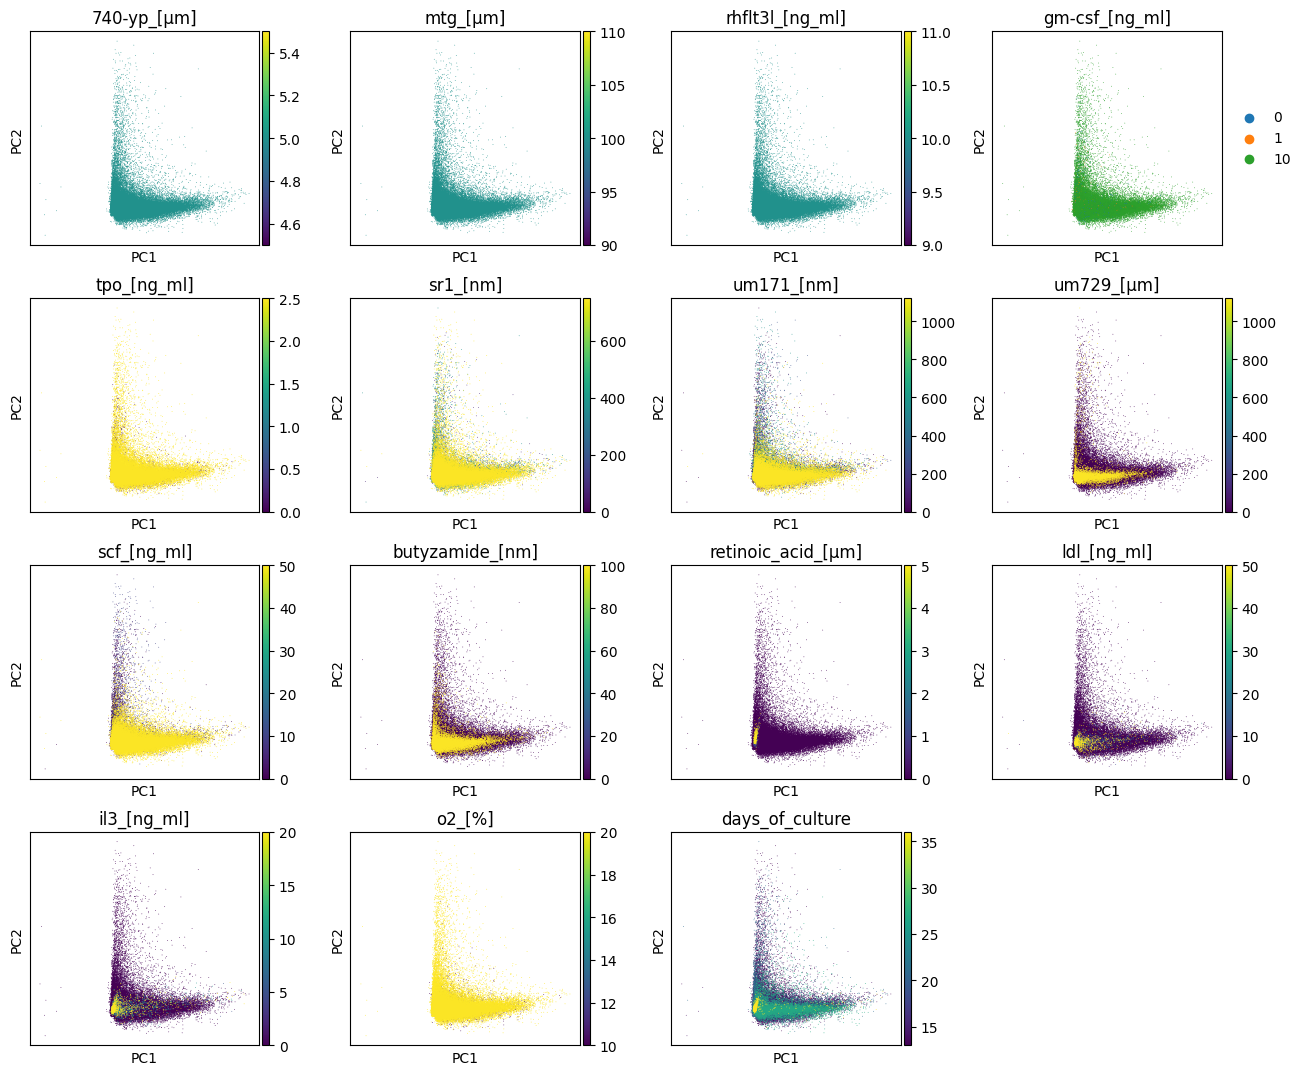

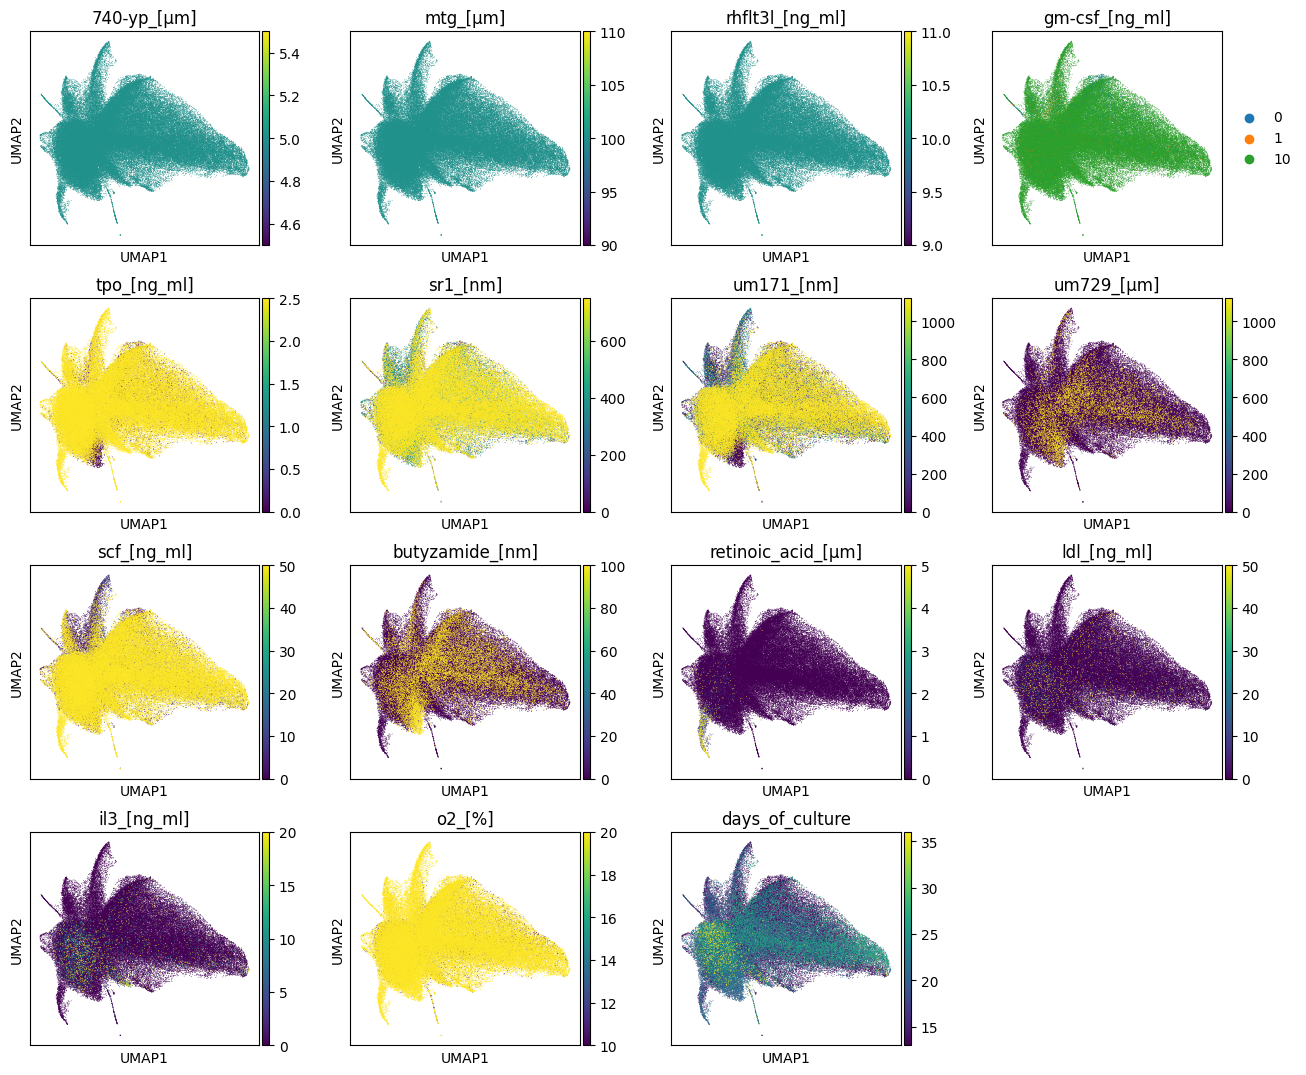

In [ ]:
# COLUMNS = [
#     'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]',
#     'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]',
#     'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]', "experiment_id", "replicate", "well_id", 
#     "plate", "date", "days_of_culture", "source_cell_phenotype", "protocol",
# ]
COLUMNS = ["740-yp_[µm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]", "tpo_[ng_ml]", "sr1_[nm]", "um171_[nm]", "um729_[µm]", "scf_[ng_ml]", "butyzamide_[nm]", "retinoic_acid_[µm]", "ldl_[ng_ml]", "il3_[ng_ml]", "o2_[%]", "days_of_culture"]
 
sc.pl.embedding(adata_subsample, color=COLUMNS, basis="pca")
sc.pl.embedding(adata_subsample, color=COLUMNS, basis="umap")


### Sampling Channel Features from the Flow Model.

In [ ]:
NUM_SAMPLES_PER_PROTOCOL = 1_000
samples_per_protocol = {}
for protocol_id, protocol_ohe in tqdm(adata.uns[UNS_KEY].items()):
    protocol_ohe = torch.from_numpy(protocol_ohe).\
        unsqueeze(0).repeat(NUM_SAMPLES_PER_PROTOCOL, 1).\
            float().to(flow_matching.device)
    samples_per_protocol[protocol_id] = flow_matching.predict(
        {
            "condition": {COND_REPR: protocol_ohe}
        }
    ).detach().cpu().numpy()


100%|██████████| 117/117 [00:04<00:00, 25.96it/s]


### Mapping encoded protocol id to their original values.

In [ ]:
def retrieve_original_protocol_vals(str_id, columns=EXPERIMENTAL_COLUMNS):
    col_vals = str_id.split("_")
    assert len(col_vals) == len(columns)
    return {col:float(col_vals[idx]) for idx, col in enumerate(columns)}

obs_dict = {col: [] for col in EXPERIMENTAL_COLUMNS}
for protocol_str in adata.uns[UNS_KEY].keys():
    protocol_values = retrieve_original_protocol_vals(protocol_str)
    for protocol_axis, protocol_value in protocol_values.items():
        obs_dict[protocol_axis].extend([protocol_value for _ in range(NUM_SAMPLES_PER_PROTOCOL)])


AssertionError: 

### Constructing the augmented adata with generated samples.

In [ ]:
X_repr_generated = np.concatenate(
    list(samples_per_protocol.values()), axis=0
)
X_repr_generated = np.concatenate(
    [adata_subsample.obsm[OBSM_KEY], X_repr_generated], axis=0
)
obs_generated = pd.DataFrame(obs_dict)
obs_generated = pd.concat(
    [adata_subsample.obs[EXPERIMENTAL_COLUMNS], obs_generated]
)
obs_generated["dataset"] = ["real" for _ in range(adata_subsample.shape[0])] +\
    ["generated" for _ in range(len(adata_subsample.uns[UNS_KEY])*NUM_SAMPLES_PER_PROTOCOL)]
obs_generated["gm-csf_[ng/ml]"] = obs_generated["gm-csf_[ng/ml]"].astype(int)
for col in EXPERIMENTAL_COLUMNS:
    obs_generated[col].astype(adata.obs[col].dtype)
adata_generated = sc.AnnData(
    X=X_repr_generated,
    obs=obs_generated,
    layers={OBSM_KEY: X_repr_generated}
)
adata_generated


/tmp/ipykernel_3691566/3522678040.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  obs_generated = pd.concat(


ValueError: Length of values (210275) does not match length of index (93275)

### Compute PCs, Neighbor Graph and UMAP of Data.

In [ ]:
sc.pp.pca(adata_generated, layer=OBSM_KEY)
sc.pp.neighbors(adata_generated)
sc.tl.umap(adata_generated)
adata_generated


AnnData object with n_obs × n_vars = 166278 × 21
    obs: 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]', 'dataset'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_repr'
    obsp: 'distances', 'connectivities'

### Visualizing the Dimensionality Reduced Data.


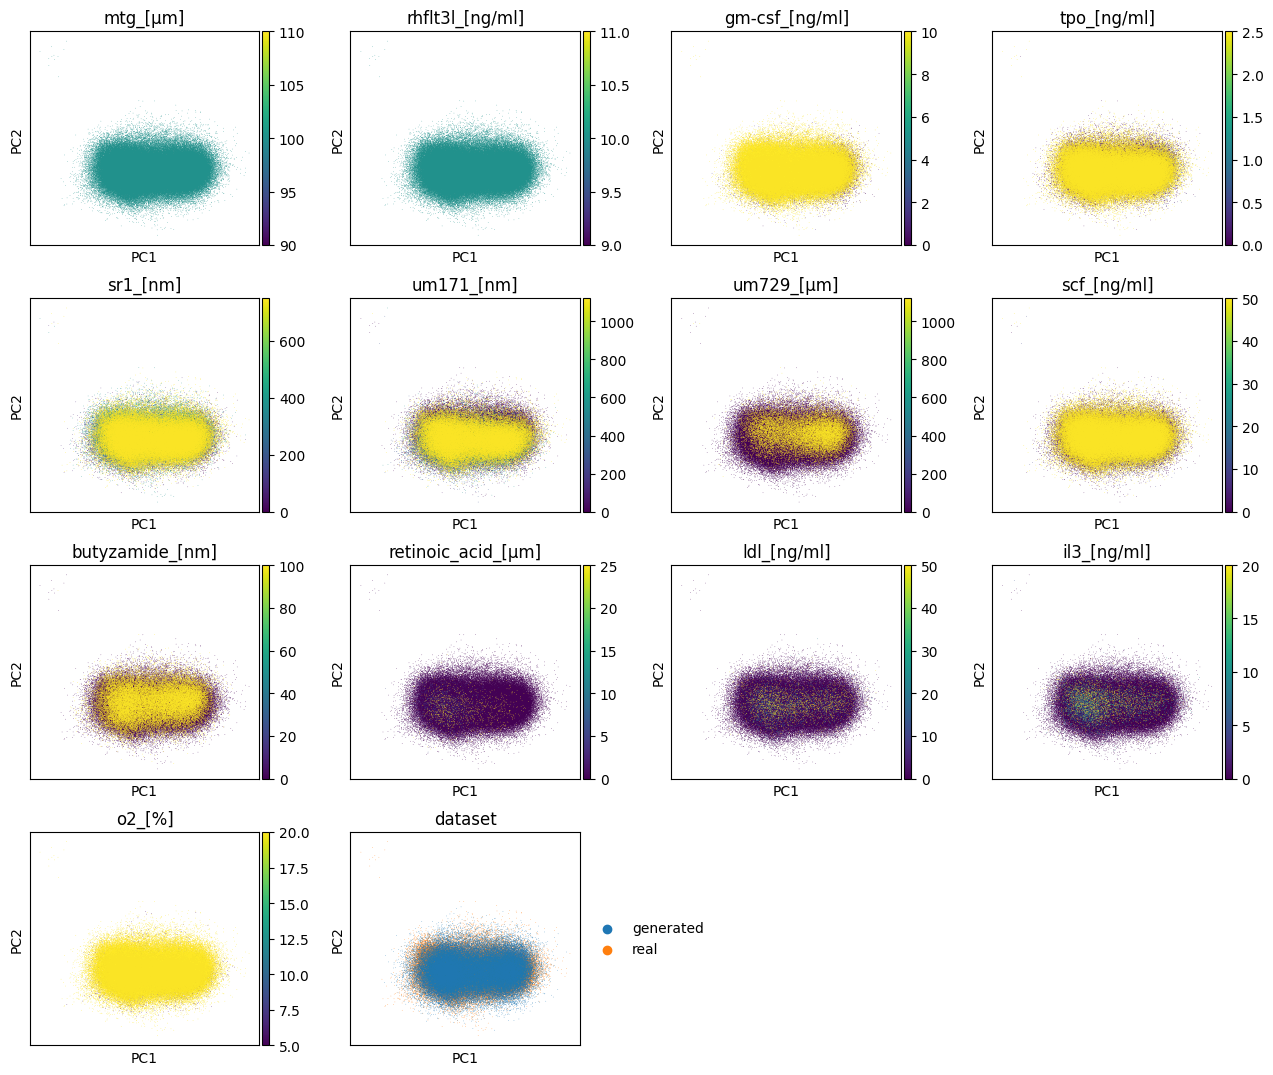

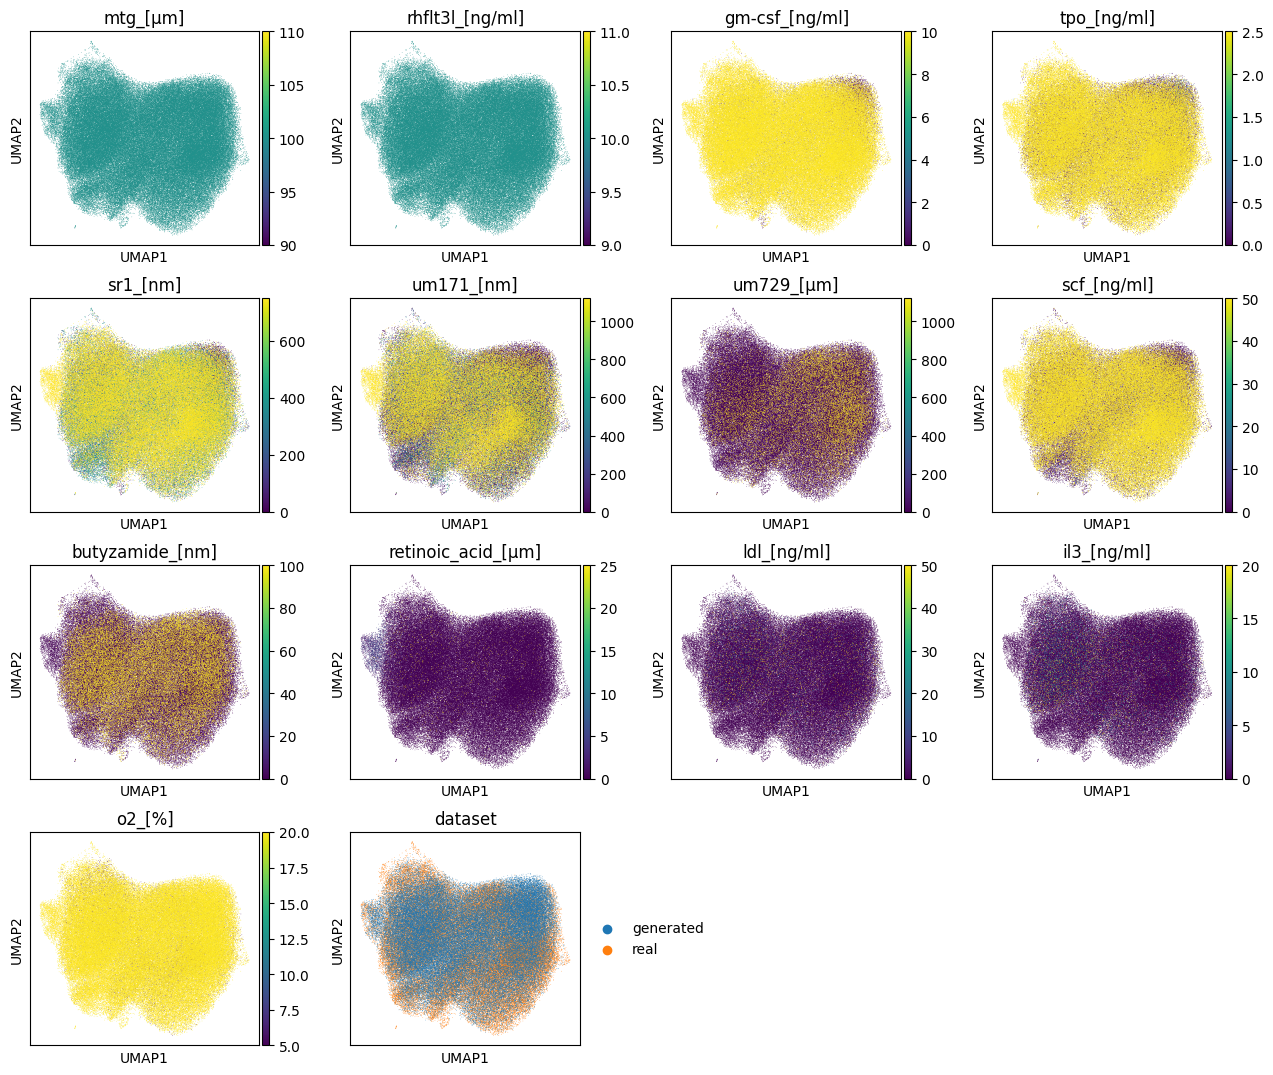

In [ ]:
sc.pl.embedding(adata_generated, color=adata_generated.obs.columns, basis="pca")
sc.pl.embedding(adata_generated, color=adata_generated.obs.columns, basis="umap")


### Visualizing the marginal distribution over the channels.

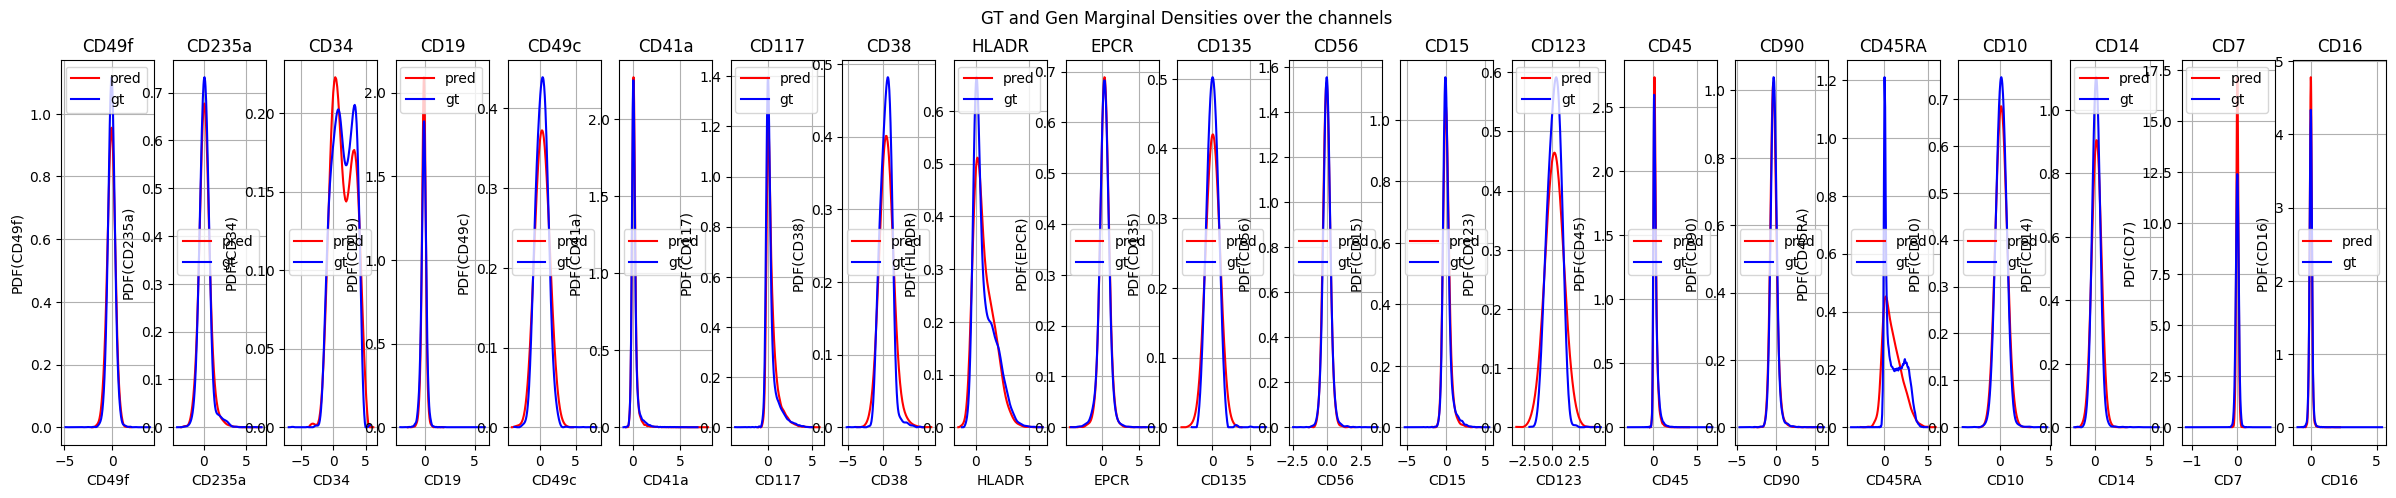

In [ ]:
X_repr_generated = np.concatenate(
    list(samples_per_protocol.values()), axis=0
)
fig, axes = plt.subplots(1, X_repr_generated.shape[-1], figsize=(30, 5))
fig.suptitle("GT and Gen Marginal Densities over the channels")
for idx, col in enumerate(adata.var_names): 
    fastkde.pdf(X_repr_generated[:, idx], var_names=[col, ]).plot(color="red", ax=axes[idx], label="pred")
    fastkde.pdf(adata_subsample.obsm[OBSM_KEY][:, idx], var_names=[col, ]).plot(color="blue", ax=axes[idx], label="gt")
    axes[idx].set_title(col)
    axes[idx].grid(True)
    axes[idx].legend()
fig.show()


### Computing metrics between real and generated data.

In [ ]:
evaluation_dict = {
    "protocol_id": [],
    "N": [],
    "e_distance": [],
    "mmd": [],
    **{col: [] for col in EXPERIMENTAL_COLUMNS}
}
for idx, (protocol_id, protocol_samples) in enumerate(samples_per_protocol.items()):
    original_samples = adata_subsample[adata_subsample.obs[OBS_KEY]==protocol_id].obsm[OBSM_KEY]
    print(f"Evaluating protocol {idx}. Found {original_samples.shape[0]} samples.")
    if original_samples.shape[0] == 0:
        continue
    e_distance = compute_e_distance(protocol_samples, original_samples)
    mmd = compute_mmd(protocol_samples, original_samples)
    evaluation_dict["protocol_id"].append(protocol_id)
    evaluation_dict["N"].append(original_samples.shape[0])
    evaluation_dict["e_distance"].append(e_distance)
    evaluation_dict["mmd"].append(mmd)
    protocol_values = retrieve_original_protocol_vals(protocol_id)
    for protocol_axis, protocol_value in protocol_values.items():
        evaluation_dict[protocol_axis].append(protocol_value)
evaluation_df = pd.DataFrame(evaluation_dict)
evaluation_df


Evaluating protocol 0. Found 1006 samples.
Evaluating protocol 1. Found 1200 samples.
Evaluating protocol 2. Found 804 samples.
Evaluating protocol 3. Found 1491 samples.
Evaluating protocol 4. Found 1112 samples.
Evaluating protocol 5. Found 105 samples.
Evaluating protocol 6. Found 68 samples.
Evaluating protocol 7. Found 46 samples.
Evaluating protocol 8. Found 506 samples.
Evaluating protocol 9. Found 47 samples.
Evaluating protocol 10. Found 122 samples.
Evaluating protocol 11. Found 1954 samples.
Evaluating protocol 12. Found 929 samples.
Evaluating protocol 13. Found 747 samples.
Evaluating protocol 14. Found 217 samples.
Evaluating protocol 15. Found 1437 samples.
Evaluating protocol 16. Found 1009 samples.
Evaluating protocol 17. Found 1610 samples.
Evaluating protocol 18. Found 1445 samples.
Evaluating protocol 19. Found 1102 samples.
Evaluating protocol 20. Found 49 samples.
Evaluating protocol 21. Found 43 samples.
Evaluating protocol 22. Found 1861 samples.
Evaluating prot

,protocol_id,N,e_distance,mmd,mtg_[µm],rhflt3l_[ng/ml],gm-csf_[ng/ml],tpo_[ng/ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng/ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng/ml],il3_[ng/ml],o2_[%]
0,100_10_10_2.5_75_0.0_0.75_50_0_0_0_0.0_20,1006,0.093818,0.003143,100.0,10.0,10.0,2.5,75.0,0.0,0.75,50.0,0.0,0.0,0.0,0.0,20.0
1,100_10_10_2.5_375_1120.0_0.0_50_0_0_0_0.0_20,1200,0.091473,0.002571,100.0,10.0,10.0,2.5,375.0,1120.0,0.00,50.0,0.0,0.0,0.0,0.0,20.0
2,100_10_10_2.5_75_1120.0_0.0_50_0_0_0_0.0_20,804,0.108026,0.002775,100.0,10.0,10.0,2.5,75.0,1120.0,0.00,50.0,0.0,0.0,0.0,0.0,20.0
3,100_10_10_2.5_375_560.0_0.0_50_0_0_0_0.0_20,1491,0.073364,0.002212,100.0,10.0,10.0,2.5,375.0,560.0,0.00,50.0,0.0,0.0,0.0,0.0,20.0
4,100_10_10_2.5_75_560.0_0.0_50_0_0_0_0.0_20,1112,0.016263,0.002233,100.0,10.0,10.0,2.5,75.0,560.0,0.00,50.0,0.0,0.0,0.0,0.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,100_10_1_0.0_0_0.0_1.5_0_100_0_0_0.0_20,202,0.075045,0.007236,100.0,10.0,1.0,0.0,0.0,0.0,1.50,0.0,100.0,0.0,0.0,0.0,20.0
68,100_10_1_0.0_75_0.0_1.5_0_100_0_0_0.0_20,181,0.152164,0.006960,100.0,10.0,1.0,0.0,75.0,0.0,1.50,0.0,100.0,0.0,0.0,0.0,20.0
69,100_10_1_0.0_375_0.0_1.5_0_100_0_0_0.0_20,82,0.289244,0.012366,100.0,10.0,1.0,0.0,375.0,0.0,1.50,0.0,100.0,0.0,0.0,0.0,20.0
70,100_10_10_0.0_0_0.0_1.5_0_100_0_0_0.0_20,208,0.045588,0.005576,100.0,10.0,10.0,0.0,0.0,0.0,1.50,0.0,100.0,0.0,0.0,0.0,20.0


### What is the distribution of Number of cells per protocols?

<Axes: xlabel='N', ylabel='Count'>

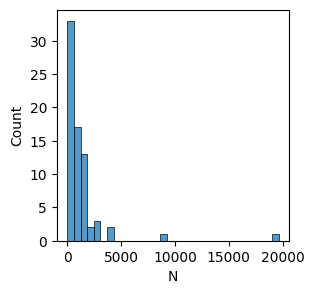

In [ ]:
sns.histplot(evaluation_df, x="N")


### Inspecting the relations between the metrics.

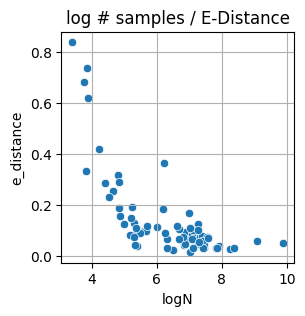

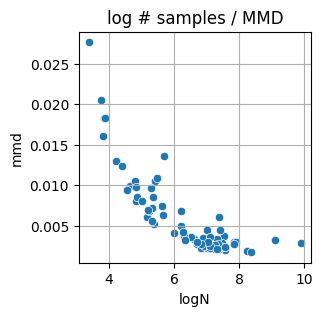

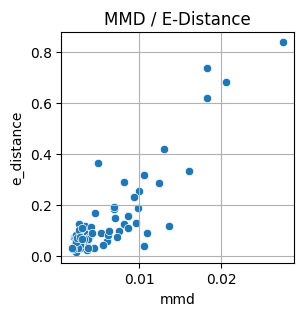

In [ ]:
evaluation_df["logN"] = np.log(evaluation_df["N"])
plt.figure()
plt.title("log # samples / E-Distance")
sns.scatterplot(evaluation_df, x="logN", y="e_distance")
plt.grid(True)

plt.figure()
plt.title("log # samples / MMD")
sns.scatterplot(evaluation_df, x="logN", y="mmd")
plt.grid(True)


plt.figure()
plt.title("MMD / E-Distance")
sns.scatterplot(evaluation_df, x="mmd", y="e_distance")
plt.grid(True)


### Pulling back samples to noise and inspecting the pulled back distribution.

  0%|          | 0/73 [00:00<?, ?it/s]/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 73/73 [00:06<00:00, 11.06it/s]


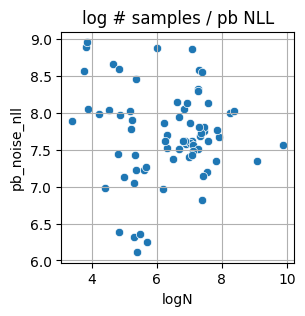

In [ ]:
if "pb_noise_nll" in evaluation_dict:
    evaluation_dict.pop("pb_noise_nll")
for protocol_id, protocol_ohe in tqdm(adata.uns[UNS_KEY].items()):
    original_samples = torch.from_numpy(adata_subsample[adata_subsample.obs[OBS_KEY]==protocol_id].obsm[OBSM_KEY]).\
        float().to(flow_matching.device)
    if original_samples.shape[0]==0:
        continue
    protocol_ohe = torch.from_numpy(protocol_ohe).\
        unsqueeze(0).repeat(original_samples.shape[0], 1).\
            float().to(flow_matching.device)
    vf_fn = flow_matching.velocity_field.get_vf_fn(
        cond={COND_REPR:protocol_ohe}
    )
    noise_samples = odeint(
        VF(vf_fn), original_samples,
        torch.linspace(1.0, 0.0, flow_matching.num_time_steps),
        **flow_matching.solver_kwargs
    )[-1].detach().cpu().numpy()
    if "pb_noise_nll" not in evaluation_dict.keys():
        evaluation_dict["pb_noise_nll"] = []
    noise_nll = (0.5*(np.sum(noise_samples**2, axis=-1) + np.log(2*np.pi))).mean().item()
    evaluation_dict["pb_noise_nll"].append(noise_nll)
evaluation_df = pd.DataFrame(evaluation_dict)
evaluation_df["logN"] = np.log(evaluation_df["N"])
evaluation_df


plt.figure()
plt.title("log # samples / pb NLL")
sns.scatterplot(evaluation_df, x="logN", y="pb_noise_nll")
plt.grid(True)


### Computing distances between real samples from different protocols.

In [ ]:
gt_dist = {
    "mmd": np.zeros((len(adata.uns[UNS_KEY]), len(adata.uns[UNS_KEY]))),
    "e_distance": np.zeros((len(adata.uns[UNS_KEY]), len(adata.uns[UNS_KEY]))),
}

for idx0, protocol_id0 in enumerate(adata.uns[UNS_KEY].keys()):
    print(f"computing distances to data from protocol {idx0}...")
    original_samples0 = adata_subsample[adata_subsample.obs[OBS_KEY]==protocol_id0].obsm[OBSM_KEY]
    if original_samples0.shape[0] == 0:
        gt_dist["e_distance"][idx0] = np.inf
        continue 
    for idx1, protocol_id1 in tqdm(enumerate(adata.uns[UNS_KEY].keys())):
        if idx1 <= idx0:
            gt_dist["e_distance"][idx0, idx1] = np.inf
            gt_dist["mmd"][idx0, idx1] = np.inf
            continue
        original_samples1 = adata_subsample[adata_subsample.obs[OBS_KEY]==protocol_id1].obsm[OBSM_KEY]
        if original_samples1.shape[0] == 0:
            gt_dist["e_distance"][idx0, idx1] = np.inf
            gt_dist["mmd"][idx0, idx1] = np.inf
            continue
        gt_dist["e_distance"][idx0, idx1] = compute_e_distance(original_samples0, original_samples1)
        gt_dist["mmd"][idx0, idx1] = compute_mmd(original_samples0, original_samples1)


computing distances to data from protocol 0...


33it [00:13,  1.74s/it]

73it [00:56,  1.29it/s]


computing distances to data from protocol 1...


73it [01:15,  1.04s/it]


...

73it [00:00, 2692.04it/s]


computing distances to data from protocol 71...


73it [00:00, 4258.12it/s]


computing distances to data from protocol 72...


73it [00:00, 628714.97it/s]


### Computing distances between generated samples from different protocols.


In [ ]:
gen_dist = {
    "mmd": np.zeros((len(adata.uns[UNS_KEY]), len(adata.uns[UNS_KEY]))),
    "e_distance": np.zeros((len(adata.uns[UNS_KEY]), len(adata.uns[UNS_KEY]))),
}

for idx0, (protocol_id0, generated_samples0)  in enumerate(samples_per_protocol.items()):
    print(f"computing distances to data from protocol {idx0}...")
    original_samples0 = adata_subsample[adata_subsample.obs[OBS_KEY]==protocol_id0].obsm[OBSM_KEY]
    if original_samples0.shape[0] == 0:
        gt_dist["e_distance"][idx0, :] = np.inf
        continue
    for idx1, (protocol_id1, generated_samples1)  in enumerate(samples_per_protocol.items()):
        if idx1 <= idx0:
            gt_dist["e_distance"][idx0, idx1] = np.inf
            gt_dist["mmd"][idx0, idx1] = np.inf
            continue
        original_samples1 = adata_subsample[adata_subsample.obs[OBS_KEY]==protocol_id1].obsm[OBSM_KEY]
        if original_samples1.shape[0] == 0:
            gt_dist["e_distance"][idx0, idx1] = np.inf
            gt_dist["mmd"][idx0, idx1] = np.inf
            continue
        gen_dist["e_distance"][idx0, idx1] = compute_e_distance(generated_samples0, generated_samples1)
        gen_dist["mmd"][idx0, idx1] = compute_mmd(generated_samples0, generated_samples1)


computing distances to data from protocol 0...


computing distances to data from protocol 1...
computing distances to data from protocol 2...
computing distances to data from protocol 3...
computing distances to data from protocol 4...
computing distances to data from protocol 5...
computing distances to data from protocol 6...
computing distances to data from protocol 7...
computing distances to data from protocol 8...
computing distances to data from protocol 9...
computing distances to data from protocol 10...
computing distances to data from protocol 11...
computing distances to data from protocol 12...
computing distances to data from protocol 13...
computing distances to data from protocol 14...
computing distances to data from protocol 15...
computing distances to data from protocol 16...
computing distances to data from protocol 17...
computing distances to data from protocol 18...
computing distances to data from protocol 19...
computing distances to data from protocol 20...
computing distances to data from protocol 21...
c

/tmp/ipykernel_655247/2729167041.py:7: RuntimeWarning: invalid value encountered in subtract
  sns.heatmap(gt_dist["mmd"] - gen_dist["mmd"], ax=axes[2])


Text(0.5, 1.0, 'dMMD b/w GT and Generated protocols')

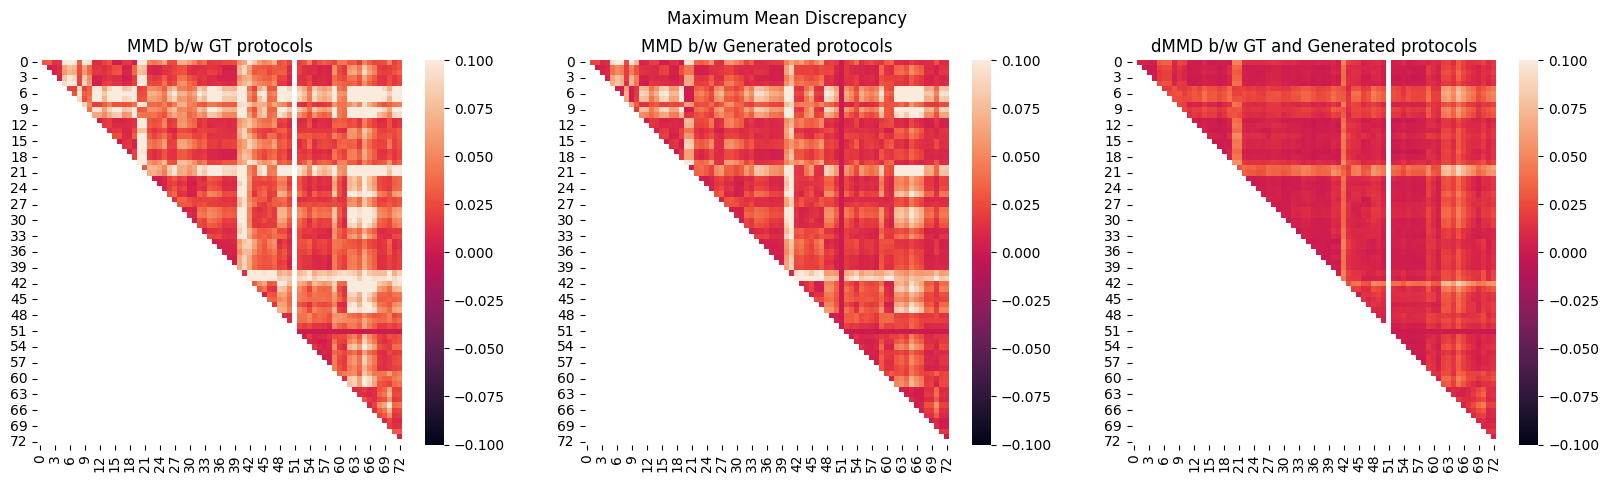

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
gt_dist["mmd"][np.tril_indices_from(gt_dist["mmd"])] = np.inf
gen_dist["mmd"][np.tril_indices_from(gen_dist["mmd"])] = np.inf
fig.suptitle("Maximum Mean Discrepancy")
sns.heatmap(gt_dist["mmd"], ax=axes[0])
sns.heatmap(gen_dist["mmd"], ax=axes[1])
sns.heatmap(gt_dist["mmd"] - gen_dist["mmd"], ax=axes[2])
axes[0].set_title("MMD b/w GT protocols")
axes[1].set_title("MMD b/w Generated protocols")
axes[2].set_title("dMMD b/w GT and Generated protocols")


/tmp/ipykernel_655247/2574320518.py:7: RuntimeWarning: invalid value encountered in subtract
  sns.heatmap(gt_dist["e_distance"] - gen_dist["e_distance"], ax=axes[2])


Text(0.5, 1.0, 'dE-distance b/w GT and Generated protocols')

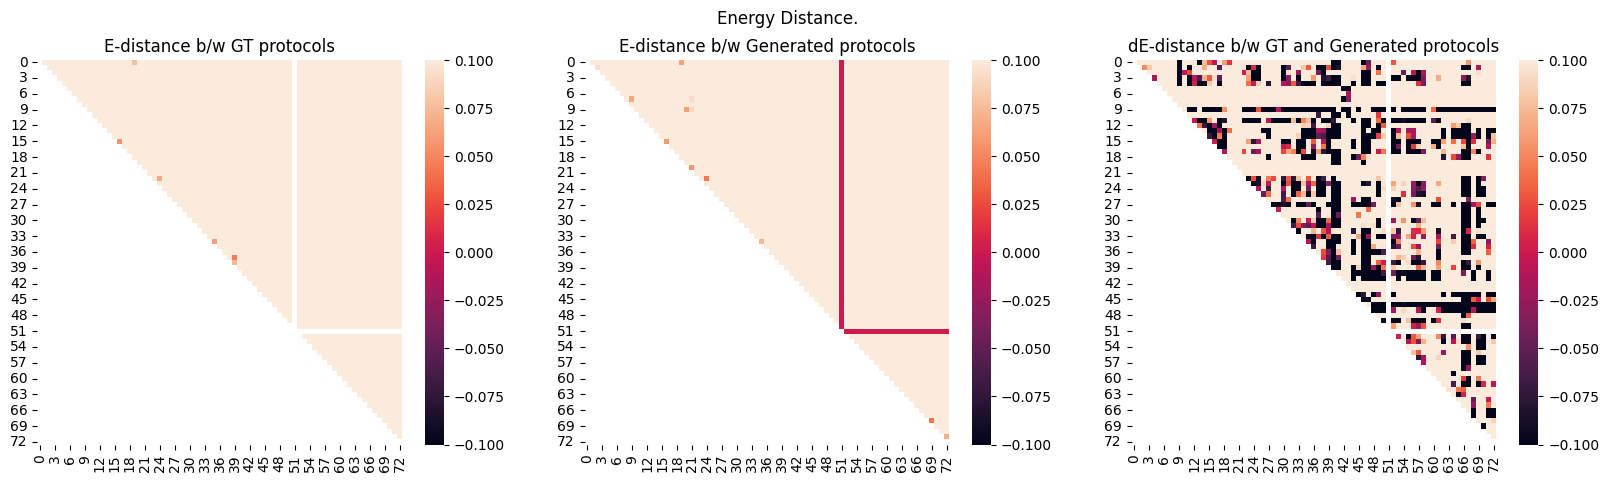

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
gt_dist["e_distance"][np.tril_indices_from(gt_dist["e_distance"])] = np.inf
gen_dist["e_distance"][np.tril_indices_from(gen_dist["e_distance"])] = np.inf
fig.suptitle("Energy Distance.")
sns.heatmap(gt_dist["e_distance"], ax=axes[0])
sns.heatmap(gen_dist["e_distance"], ax=axes[1])
sns.heatmap(gt_dist["e_distance"] - gen_dist["e_distance"], ax=axes[2])
axes[0].set_title("E-distance b/w GT protocols")
axes[1].set_title("E-distance b/w Generated protocols")
axes[2].set_title("dE-distance b/w GT and Generated protocols")
